In [1]:
%load_ext autoreload
%autoreload 2

import ipywidgets as widgets

from ipywidgets import interact
from IPython.display import Markdown, display, clear_output

from src.back_fisica import *

Using snowglobes_data module ...
Listo


In [2]:
drop_modelos = widgets.Dropdown(options=list(opciones_widget.keys()), description='Modelo:', layout=widgets.Layout(width='400px'))
drop_params  = widgets.Dropdown(options=list(opciones_widget[drop_modelos.value].keys()), description='Params:', layout=widgets.Layout(width='800px'))
drop_transformacion = widgets.Dropdown(options=list(diccionario_PH.keys()), value='Adiabática (PH = 0)', description='Transición:', layout=widgets.Layout(width='300px'))
drop_canal = widgets.Dropdown(options=list(canales_deteccion.keys()), description='Detector:', layout=widgets.Layout(width='300px'))

slider_distancia = widgets.FloatLogSlider(value=10.0, base=10, min=-1, max=3, step=0.05, description='Dist.[kpc]:', readout_format='.2f', layout=widgets.Layout(width='300px'))

boton_guardar = widgets.Button(description='Guardar Imagen', button_style='primary', layout=widgets.Layout(width='200px'))
out_mensaje = widgets.Output() 

def guardar_imagen(b):
    with out_mensaje:
        clear_output()
        mensaje = guardar_figura_actual(
            drop_modelos.value,
            drop_params.value,
            drop_canal.value,
            drop_transformacion.value,
            slider_distancia.value
        )
        print(mensaje)
        
boton_guardar.on_click(guardar_imagen)

# Control de parámetors según el modelo, se actualiza el drop segun el de modelos
def actualizar_opciones_params(*args):
    drop_params.options = list(opciones_widget[drop_modelos.value].keys())
drop_modelos.observe(actualizar_opciones_params, 'value')


controles_modelo = widgets.HBox([drop_modelos, drop_params])
controles = widgets.HBox([drop_canal, drop_transformacion, slider_distancia, boton_guardar])
master_panel = widgets.VBox([controles_modelo, controles, out_mensaje])

output_interactivo = widgets.interactive_output(
    eventos_panel_interactivo,{
        'model_family': drop_modelos,
        'model_params': drop_params,
        'nombre_transformacion': drop_transformacion,
        'nombre_canal': drop_canal,
        'distancia_kpc': slider_distancia}
)

display(master_panel, output_interactivo)

Output()

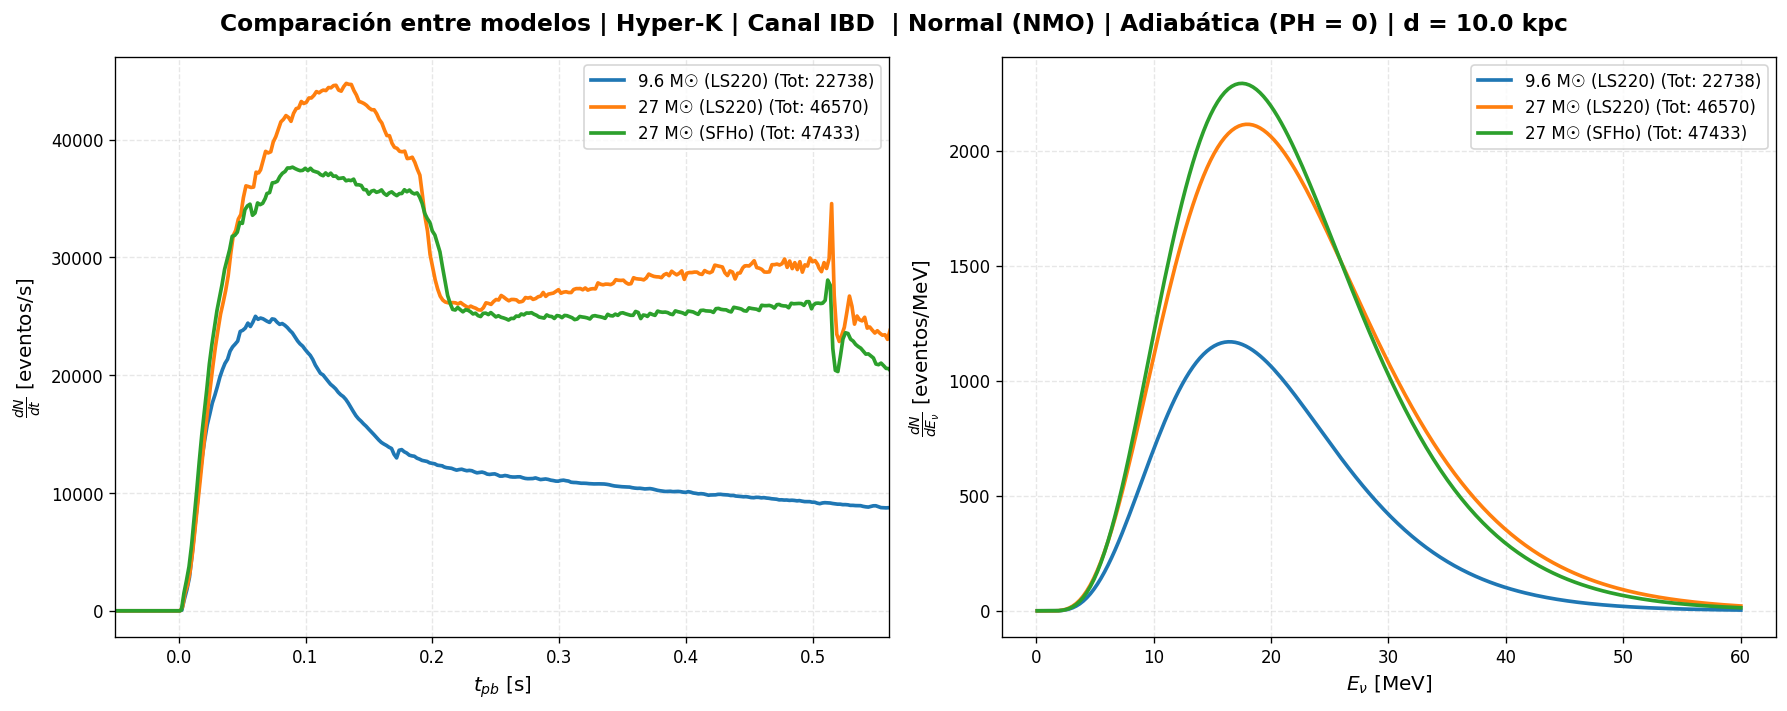

In [3]:
"""
COMPARACIÓN ENTRE MODELOS DE PROGENITORA
"""

def cargar_y_calcular_modelo(model_family, model_params):
    """
    Carga un modelo y calcula su espectro inicial.
    Usado por las funciones de comparación entre modelos.
    """
    clase_modelo = modelos_obj[model_family]
    parametros = opciones_widget[model_family][model_params]
    modelo = clase_modelo(**parametros)

    t = modelo.time
    espectro_aux = modelo.get_initial_spectra(t, energiatest)
    espectro = {flavor: data.to(1/(u.MeV*u.s)) for flavor, data in espectro_aux.items()}

    return modelo, t, espectro


def tabla_resumen_modelos(lista_modelos, P_H, jerarquia, nombre_canal, distancia_kpc=10):
    """
    Construye una tabla comparativa de observables resumen entre modelos.

    Parámetros
    ----------
    lista_modelos : list of tuple
        [(model_family, model_params), ...]
    """
    canal = canales_deteccion[nombre_canal]
    filas = []

    for model_family, model_params in lista_modelos:

        modelo, t, espectro = cargar_y_calcular_modelo(model_family, model_params)

        # Energía total liberada (integrando luminosidad sobre todo t, todos los sabores)
        energia_total = sum(
            np.trapezoid(modelo.luminosity[flavor].to(u.erg/u.s), x=t).to(u.erg)
            for flavor in Flavor
        )

        # Energía media en el pico de luminosidad (fase de acreción ~ t=0.15s aprox.)
        idx_pico = np.argmax(modelo.luminosity[Flavor.NU_E_BAR].value)
        E_media_pico = modelo.meanE[Flavor.NU_E_BAR][idx_pico].to(u.MeV)

        # Eventos totales para el canal/jerarquía seleccionados
        psurvival, psurvival_bar = calcular_probabilidades(P_H, jerarquia)
        flujo_nmo, flujo_imo = calcular_flujo_tierra(P_H, espectro, distancia_kpc)
        flujo = flujo_nmo if jerarquia == 'Normal (NMO)' else flujo_imo

        targets = canal['targets']
        if canal['tipo'] == 'cc':
            flavor = canal['flavor']
            d2NdEdT = targets * flujo[flavor] * canal['xsec']
        else:  # 'nc'
            d2NdEdT = sum(targets * flujo[fl] * canal['xsec'][fl] for fl in Flavor)

        dNdE = np.trapezoid(d2NdEdT, x=t, axis=0)
        N_total = np.trapezoid(dNdE, x=energiatest)

        filas.append({
            'Modelo':              model_family,
            'Parámetros':          model_params,
            'E_total liberada':    f"{energia_total.to(u.erg):.3e}",
            '⟨E⟩ ν̄ₑ en pico [MeV]': f"{E_media_pico:.2f}",
            'Duración [s]':        f"{t[-1].to(u.s):.3f}",
            f'N eventos ({nombre_canal})': f"{N_total:.1f}",
        })

    df = pd.DataFrame(filas)
    return df


def comparar_modelos_widget(lista_modelos, nombre_transformacion, jerarquia,
                              nombre_canal, distancia_kpc=10):
    """
    Grafica dN/dt y dN/dE superponiendo varios modelos de progenitora,
    para una jerarquía y P_H fijos.

    Parámetros
    ----------
    lista_modelos : list of tuple
        [(model_family, model_params, etiqueta), ...]
    """
    P_H = diccionario_PH[nombre_transformacion]
    canal = canales_deteccion[nombre_canal]
    targets = canal['targets']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=120)

    colores = plt.cm.tab10.colors

    for i, (model_family, model_params, etiqueta) in enumerate(lista_modelos):

        modelo, t, espectro = cargar_y_calcular_modelo(model_family, model_params)
        flujo_nmo, flujo_imo = calcular_flujo_tierra(P_H, espectro, distancia_kpc)
        flujo = flujo_nmo if jerarquia == 'Normal (NMO)' else flujo_imo

        if canal['tipo'] == 'cc':
            flavor = canal['flavor']
            d2NdEdT = targets * flujo[flavor] * canal['xsec']
        else:
            d2NdEdT = sum(targets * flujo[fl] * canal['xsec'][fl] for fl in Flavor)

        dNdE = np.trapezoid(d2NdEdT, x=t, axis=0)
        dNdT = np.trapezoid(d2NdEdT, x=energiatest, axis=1)
        total = np.trapezoid(dNdE, x=energiatest)

        color = colores[i % len(colores)]

        ax1.plot(t, dNdT, lw=2.2, color=color,
                 label=f'{etiqueta} (Tot: {total:.0f})')
        ax2.plot(energiatest, dNdE, lw=2.2, color=color,
                 label=f'{etiqueta} (Tot: {total:.0f})')

    ax1.set_xlabel(r'$t_{pb}$ [s]', fontsize=12)
    ax1.set_ylabel(r'$\frac{dN}{dt}$ [eventos/s]', fontsize=12)
    ax1.set_xlim(-0.05, 0.56)
    ax1.grid(alpha=0.3, linestyle='--')
    ax1.legend(loc='upper right', fontsize=10)

    ax2.set_xlabel(r'$E_\nu$ [MeV]', fontsize=12)
    ax2.set_ylabel(r'$\frac{dN}{dE_\nu}$ [eventos/MeV]', fontsize=12)
    ax2.grid(alpha=0.3, linestyle='--')
    ax2.legend(loc='upper right', fontsize=10)

    fig.suptitle(
        f'Comparación entre modelos | {nombre_canal} | {jerarquia} | '
        f'{nombre_transformacion} | d = {distancia_kpc:.1f} kpc',
        fontsize=14, weight='bold'
    )
    plt.tight_layout()
    plt.show()

    return fig


lista_comparar = [
    ('Sukhbold_2015', 'progenitor_mass=9.6 solMass, eos=LS220', '9.6 M☉ (LS220)'),
    ('Sukhbold_2015', 'progenitor_mass=27.0 solMass, eos=LS220', '27 M☉ (LS220)'),
    ('Sukhbold_2015', 'progenitor_mass=27.0 solMass, eos=SFHo', '27 M☉ (SFHo)'),
]

fig = comparar_modelos_widget(
    lista_comparar,
    nombre_transformacion='Adiabática (PH = 0)',
    jerarquia='Normal (NMO)',
    nombre_canal='Hyper-K | Canal IBD ',
    distancia_kpc=10
)

